# UBX Raw Measurement Parser

Parse u-blox binary (`.ubx`) recordings and extract **pseudorange** observations from `UBX-RXM-RAWX` messages.

**Data source:** `dataset/` folder — raw serial captures from u-blox receivers.

**Goal:** Plot pseudorange over time for every satellite tracked in the recording.

## 1. Install Dependencies

We use [`pyubx2`](https://github.com/semuconsulting/pyubx2) for parsing UBX binary protocol, and `matplotlib` + `pandas` for data wrangling and plotting.

In [1]:
!uv add pyubx2 pandas matplotlib

Resolved 113 packages in 4ms
Checked 110 packages in 2ms


## 2. Imports

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pyubx2 import UBXReader

## 3. Parse UBX-RXM-RAWX Messages

`RXM-RAWX` contains raw GNSS measurements. For each epoch (receiver time-of-week) we extract:

| Field | Description |
|-------|-------------|
| `rcvTow` | Receiver time of week (seconds) |
| `gnssId` | GNSS constellation (0=GPS, 1=SBAS, 2=Galileo, 3=BeiDou, 5=QZSS, 6=GLONASS) |
| `svId` | Satellite vehicle number |
| `prMes` | Pseudorange measurement (meters) |
| `cno` | Carrier-to-noise ratio (dB-Hz) |

`pyubx2` parses the repeated measurement blocks and exposes fields with a `_XX` suffix (e.g. `prMes_01`, `gnssId_01`, …).

In [14]:
DATA_DIR = Path("dataset")
# UBX_FILE = DATA_DIR / "COM3___9600_260408_034104.ubx"

# DATASET Wed 8 Apr, spoof 4,5,8,9
#UBX_FILE = DATA_DIR / "8/COM3___9600_260408_034104.ubx"
# HIGHLIGHT_PRNS = [4,5,8,9]

# DATASET Thu 9 Apr - ver1, spoof 4 5 6 10
# UBX_FILE = DATA_DIR / "9/ver1/COM4___9600_260409_022850.ubx"
# UBX_FILE = DATA_DIR / "9/ver1/COM3___9600_260409_022901.ubx"
# HIGHLIGHT_PRNS = [4,5,6,10]

# DATASET Thu 9 Apr - ver2, spoof 4, 5, 10 ,11, 12, 15, 16
# UBX_FILE = DATA_DIR / "9/ver2/COM4___9600_260409_024636.ubx"
# UBX_FILE = DATA_DIR / "9/ver2/COM3___9600_260409_023906.ubx"
# HIGHLIGHT_PRNS = [ 4, 5, 10 ,11, 12, 15, 16]

# DATASET Fri 10 Apr, spoof 3,4
# UBX_FILE = DATA_DIR / "10/com3.ubx"
# HIGHLIGHT_PRNS = [ 4, 5, 10 ,11, 12, 15, 16]


# Spoof revive 22, 14, 30 - đúng nhất đến thời điểm hiện tại
# UBX_FILE = DATA_DIR / "22-4/ver3/COM4___9600_260422_082748.ubx"

UBX_FILE = DATA_DIR / "22-4/ver3/COM3___9600_260422_082740.ubx"


# HIGHLIGHT_PRNS = [ 7, 8]

# UBX_FILE = DATA_DIR / "22-4/ver2/COM3___9600_260422_081215.ubx"



HIGHLIGHT_PRNS = [22,14,30 ]

In [15]:
GNSS_NAMES = {0: "GPS", 1: "SBAS", 2: "GAL", 3: "BDS", 5: "QZSS", 6: "GLO"}


def parse_rxm_rawx(filepath: Path) -> pd.DataFrame:
    """Parse all RXM-RAWX messages and return a flat DataFrame of measurements."""
    records = []
    total_messages = 0
    rawx_messages = 0
    skipped_rawx = 0

    with open(filepath, "rb") as f:
        reader = UBXReader(f, protfilter=2)  # UBX only
        for raw, parsed in reader:
            if parsed is None:
                continue

            total_messages += 1
            if parsed.identity != "RXM-RAWX":
                continue

            rawx_messages += 1
            msg = parsed.__dict__ if not hasattr(parsed, "val") else parsed.val
            rcv_tow = msg.get("rcvTow") or getattr(parsed, "rcvTow", None)
            num_meas = msg.get("numMeas") or getattr(parsed, "numMeas", None)

            # Some captures contain malformed zero-length RAWX packets like b562021500001747.
            # Skipping them preserves the rest of the recording instead of truncating at the first bad packet.
            if rcv_tow is None or num_meas is None:
                skipped_rawx += 1
                continue

            for i in range(1, num_meas + 1):
                suffix = f"_{i:02d}"
                pr = msg.get(f"prMes{suffix}") or getattr(parsed, f"prMes{suffix}", None)
                cp = msg.get(f"cpMes{suffix}") or getattr(parsed, f"cpMes{suffix}", None)
                gnss_id = msg.get(f"gnssId{suffix}") or getattr(parsed, f"gnssId{suffix}", None)
                sv_id = msg.get(f"svId{suffix}") or getattr(parsed, f"svId{suffix}", None)
                cno = msg.get(f"cno{suffix}") or getattr(parsed, f"cno{suffix}", None)

                if sv_id is None:
                    continue

                if isinstance(gnss_id, str):
                    constellation = gnss_id
                else:
                    constellation = GNSS_NAMES.get(gnss_id, f"GNSS{gnss_id}")  # ty:ignore[no-matching-overload]

                if pr is not None and pr > 0:
                    records.append(
                        {
                            "rcvTow": rcv_tow,
                            "gnssId": gnss_id,
                            "svId": sv_id,
                            "constellation": constellation,
                            "sat": f"{constellation}{sv_id:02d}",
                            "prMes": pr,
                            "cpMes": cp,
                            "cno": cno,
                        }
                    )

    df = pd.DataFrame(records)
    if df.empty:
        print(
            f"Read {total_messages} UBX messages, saw {rawx_messages} RAWX packets, skipped {skipped_rawx} malformed RAWX packets, and found no valid measurements."
        )
        return df

    epochs = pd.Series(sorted(df["rcvTow"].unique()))
    span_s = epochs.iloc[-1] - epochs.iloc[0]
    gaps = epochs.diff().dropna()
    largest_gap_s = gaps.max() if not gaps.empty else 0.0

    print(
        f"Read {total_messages} UBX messages, saw {rawx_messages} RAWX packets, skipped {skipped_rawx} malformed RAWX packets, and kept {len(epochs)} epochs over {span_s:.1f} s."
    )
    if largest_gap_s > 1.5:
        print(f"Largest RAWX gap: {largest_gap_s:.1f} s")

    return df

df = parse_rxm_rawx(UBX_FILE)
if df.empty:
    print("No valid RXM-RAWX measurements found.")
else:
    print(
        f"Parsed {len(df)} measurements from {df['rcvTow'].nunique()} epochs, {df['sat'].nunique()} satellites, {df['rcvTow'].max() - df['rcvTow'].min():.1f} s of receiver time."
    )


Read 12442 UBX messages, saw 255 RAWX packets, skipped 0 malformed RAWX packets, and kept 255 epochs over 254.0 s.
Parsed 3605 measurements from 255 epochs, 11 satellites, 254.0 s of receiver time.


## 4. Plot Pseudorange Over Time

Each line represents one satellite. The x-axis is receiver time-of-week (seconds into the GPS week), and the y-axis is the pseudorange in meters.

Set `highlight_prns` to a list such as `[4, 5, 10, 16]` to emphasize selected PRNs; the remaining satellites are drawn in gray for contrast.

Pseudorange values are typically in the range **~20,000 km – 26,000 km** for MEO GNSS satellites.

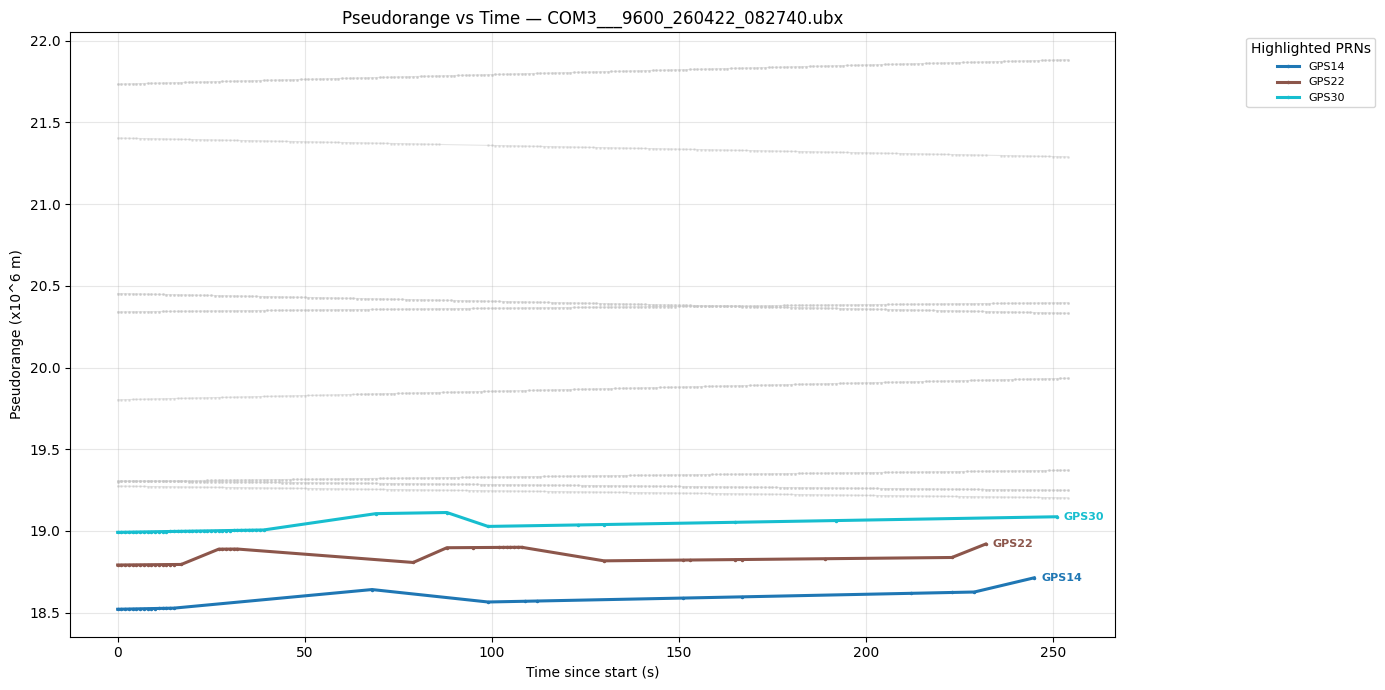

In [16]:
# Normalize time axis to start from 0
t0 = df["rcvTow"].min()
df["t_sec"] = df["rcvTow"] - t0

sats = sorted(df["sat"].unique())
default_cmap = plt.get_cmap("tab20", len(sats))
colors = {sat: default_cmap(i) for i, sat in enumerate(sats)}
sat_groups = {sat: df[df["sat"] == sat].sort_values("t_sec") for sat in sats}

highlight_tokens = {str(prn).strip().upper() for prn in HIGHLIGHT_PRNS}
highlight_sv_ids = {int(token) for token in highlight_tokens if token.isdigit()}
highlight_sat_ids = {token for token in highlight_tokens if not token.isdigit()}

highlighted_sats = []
for sat, grp in sat_groups.items():
    sat_name = str(grp["sat"].iloc[0]).upper()
    sv_id = grp["svId"].iloc[0]
    if pd.notna(sv_id):
        sv_id = int(sv_id)
    if sat_name in highlight_sat_ids or sv_id in highlight_sv_ids:
        highlighted_sats.append(sat)

fig, ax = plt.subplots(figsize=(14, 7))

if highlighted_sats:
    muted_color = "#c7c7c7"
    highlight_cmap = plt.get_cmap("tab10", len(highlighted_sats))
    highlight_colors = {sat: highlight_cmap(i) for i, sat in enumerate(highlighted_sats)}

    for sat in sats:
        if sat in highlighted_sats:
            continue
        grp = sat_groups[sat]
        ax.plot(
            grp["t_sec"],
            grp["prMes"] / 1e6,
            color=muted_color,
            marker=".",
            markersize=2,
            linewidth=0.8,
            alpha=0.45,
            zorder=1,
        )

    for sat in highlighted_sats:
        grp = sat_groups[sat]
        ax.plot(
            grp["t_sec"],
            grp["prMes"] / 1e6,
            label=sat,
            color=highlight_colors[sat],
            marker=".",
            markersize=3,
            linewidth=2.2,
            zorder=3,
        )
        ax.annotate(
            sat,
            xy=(grp["t_sec"].iloc[-1], grp["prMes"].iloc[-1] / 1e6),
            fontsize=8,
            fontweight="bold",
            color=highlight_colors[sat],
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
        )
else:
    print(f"No satellites matched highlight_prns={HIGHLIGHT_PRNS}. Plotting all satellites with default colors.")
    for sat in sats:
        grp = sat_groups[sat]
        ax.plot(
            grp["t_sec"],
            grp["prMes"] / 1e6,
            label=sat,
            color=colors[sat],
            marker=".",
            markersize=2,
            linewidth=0.8,
        )
        ax.annotate(
            sat,
            xy=(grp["t_sec"].iloc[-1], grp["prMes"].iloc[-1] / 1e6),
            fontsize=7,
            fontweight="bold",
            color=colors[sat],
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
        )

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("Pseudorange (x10^6 m)")
ax.set_title(f"Pseudorange vs Time — {UBX_FILE.name}")
if highlighted_sats:
    ax.legend(title="Highlighted PRNs", bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=8)
else:
    ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Summary Statistics

Quick overview: measurement count, mean C/N0, and pseudorange range per satellite.

In [17]:
summary = (
    df.groupby("sat")
    .agg(
        epochs=("rcvTow", "nunique"),
        mean_cno=("cno", "mean"),
        pr_min=("prMes", "min"),
        pr_max=("prMes", "max"),
    )
    .round(2)
    .sort_index()
)
summary["pr_range_km"] = ((summary["pr_max"] - summary["pr_min"]) / 1e3).round(2)
summary

,epochs,mean_cno,pr_min,pr_max,pr_range_km
sat,,,,,
GPS05,255,32.10,19302379.42,19371256.84,68.88
GPS11,255,27.22,20340519.36,20396521.67,56.00
GPS12,255,32.77,21734323.93,21883506.34,149.18
GPS13,255,35.05,19202508.18,19274244.54,71.74
GPS14,26,37.81,18520647.15,18713144.66,192.50
GPS15,255,34.09,20332274.24,20453029.82,120.76
GPS20,255,32.12,19248480.91,19306871.88,58.39
GPS21,255,26.14,19802634.24,19934298.00,131.66
GPS22,41,30.27,18791455.48,18919399.50,127.94


## 6. Carrier Phase Over Time

Carrier phase (`cpMes`) in cycles, plotted per satellite. Carrier phase is a much more precise (but ambiguous) range observable compared to pseudorange.

/var/folders/36/tkc64gps38s9nzp5s6dtqkpw0000gn/T/ipykernel_6232/3025819732.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(sats))


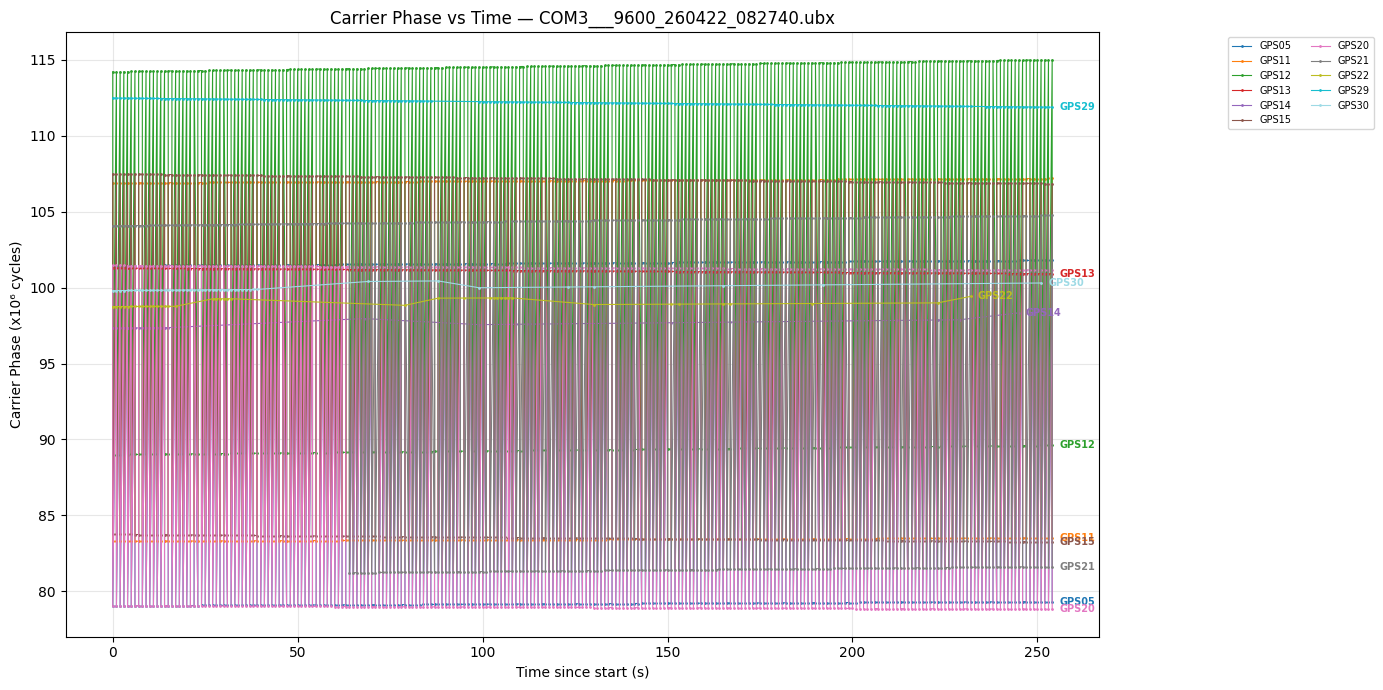

In [18]:
t0 = df["rcvTow"].min()
df["t_sec"] = df["rcvTow"] - t0

sats = sorted(df["sat"].unique())
cmap = plt.cm.get_cmap("tab20", len(sats))
colors = {sat: cmap(i) for i, sat in enumerate(sats)}

fig, ax = plt.subplots(figsize=(14, 7))

for sat in sats:
    grp = df[df["sat"] == sat].sort_values("t_sec")
    cp = grp["cpMes"].dropna()
    if cp.empty:
        continue
    ax.plot(grp.loc[cp.index, "t_sec"], cp / 1e6, label=sat, color=colors[sat],
            marker=".", markersize=2, linewidth=0.8)
    ax.annotate(sat, xy=(grp.loc[cp.index[-1], "t_sec"], cp.iloc[-1] / 1e6),
                fontsize=7, fontweight="bold", color=colors[sat],
                xytext=(5, 0), textcoords="offset points", va="center")

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("Carrier Phase (x10⁶ cycles)")
ax.set_title(f"Carrier Phase vs Time — {UBX_FILE.name}")
ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 7. C/N0 Over Time

Carrier-to-noise density ratio (dB-Hz) per satellite. Higher C/N0 indicates a stronger, cleaner signal. Typical values range from ~25 dB-Hz (weak) to ~50 dB-Hz (strong, open sky).

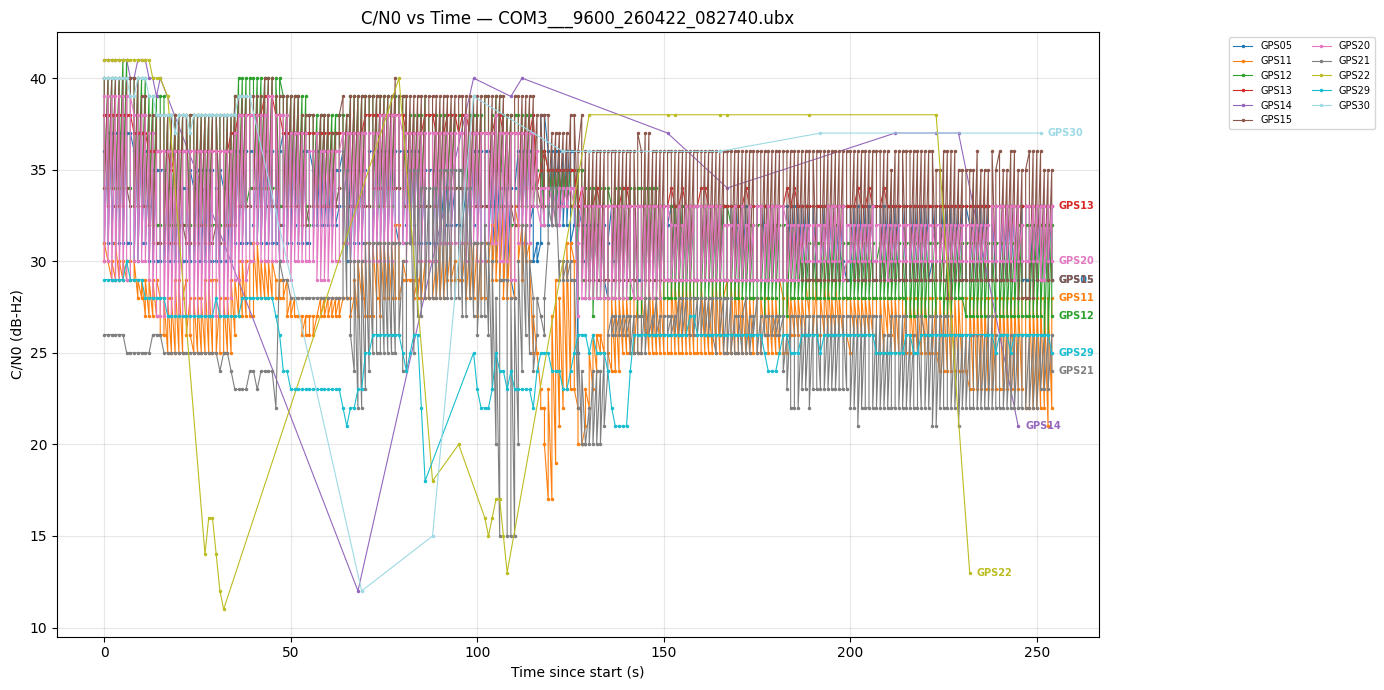

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

for sat in sats:
    grp = df[df["sat"] == sat].sort_values("t_sec")
    cno = grp["cno"].dropna()
    if cno.empty:
        continue
    ax.plot(grp.loc[cno.index, "t_sec"], cno, label=sat, color=colors[sat],
            marker=".", markersize=3, linewidth=0.8)
    ax.annotate(sat, xy=(grp.loc[cno.index[-1], "t_sec"], cno.iloc[-1]),
                fontsize=7, fontweight="bold", color=colors[sat],
                xytext=(5, 0), textcoords="offset points", va="center")

ax.set_xlabel("Time since start (s)")
ax.set_ylabel("C/N0 (dB-Hz)")
ax.set_title(f"C/N0 vs Time — {UBX_FILE.name}")
ax.legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Parse NAV-SIG and NAV-SAT

`NAV-SIG` exposes per-signal solution-use flags such as `prUsed`, `doUsed`, and `crUsed`. `NAV-SAT` exposes per-satellite flags such as `svUsed` and ephemeris availability. Flattening both messages makes it easier to inspect which PRNs the receiver is actually using over time.

In [20]:
def _msg_attr(msg: dict, parsed, name: str):
    if name in msg:
        return msg[name]
    return getattr(parsed, name, None)


def _constellation_name(gnss_id):
    if isinstance(gnss_id, str):
        return gnss_id
    return GNSS_NAMES.get(gnss_id, f"GNSS{gnss_id}")


def _add_itow_axis(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.sort_values(["iTOW_ms", "sat"]).reset_index(drop=True)
    df["t_sec"] = (df["iTOW_ms"] - df["iTOW_ms"].min()) / 1000.0
    return df


def parse_nav_sig(filepath: Path) -> pd.DataFrame:
    records = []

    with open(filepath, "rb") as f:
        reader = UBXReader(f, protfilter=2)
        for raw, parsed in reader:
            if parsed is None or parsed.identity != "NAV-SIG":
                continue

            msg = parsed.__dict__ if not hasattr(parsed, "val") else parsed.val
            i_tow_ms = _msg_attr(msg, parsed, "iTOW")
            num_sigs = _msg_attr(msg, parsed, "numSigs")
            if i_tow_ms is None or num_sigs is None:
                continue

            for i in range(1, num_sigs + 1):
                suffix = f"_{i:02d}"
                gnss_id = _msg_attr(msg, parsed, f"gnssId{suffix}")
                sv_id = _msg_attr(msg, parsed, f"svId{suffix}")
                sig_id = _msg_attr(msg, parsed, f"sigId{suffix}")
                if sv_id is None:
                    continue

                constellation = _constellation_name(gnss_id)
                sat = f"{constellation}{int(sv_id):02d}"
                signal = str(sig_id) if sig_id is not None else "UNKNOWN"

                records.append(
                    {
                        "iTOW_ms": i_tow_ms,
                        "gnssId": gnss_id,
                        "svId": int(sv_id),
                        "constellation": constellation,
                        "sat": sat,
                        "sigId": signal,
                        "sat_sig": f"{sat}/{signal}",
                        "cno": _msg_attr(msg, parsed, f"cno{suffix}"),
                        "prRes": _msg_attr(msg, parsed, f"prRes{suffix}"),
                        "qualityInd": _msg_attr(msg, parsed, f"qualityInd{suffix}"),
                        "health": _msg_attr(msg, parsed, f"health{suffix}"),
                        "prSmoothed": _msg_attr(msg, parsed, f"prSmoothed{suffix}"),
                        "prUsed": _msg_attr(msg, parsed, f"prUsed{suffix}"),
                        "crUsed": _msg_attr(msg, parsed, f"crUsed{suffix}"),
                        "doUsed": _msg_attr(msg, parsed, f"doUsed{suffix}"),
                        "prCorrUsed": _msg_attr(msg, parsed, f"prCorrUsed{suffix}"),
                        "crCorrUsed": _msg_attr(msg, parsed, f"crCorrUsed{suffix}"),
                        "doCorrUsed": _msg_attr(msg, parsed, f"doCorrUsed{suffix}"),
                    }
                )

    return _add_itow_axis(pd.DataFrame(records))


def parse_nav_sat(filepath: Path) -> pd.DataFrame:
    records = []

    with open(filepath, "rb") as f:
        reader = UBXReader(f, protfilter=2)
        for raw, parsed in reader:
            if parsed is None or parsed.identity != "NAV-SAT":
                continue

            msg = parsed.__dict__ if not hasattr(parsed, "val") else parsed.val
            i_tow_ms = _msg_attr(msg, parsed, "iTOW")
            num_svs = _msg_attr(msg, parsed, "numSvs")

            if i_tow_ms is None or num_svs is None:
                continue

            for i in range(1, num_svs + 1):
                suffix = f"_{i:02d}"
                gnss_id = _msg_attr(msg, parsed, f"gnssId{suffix}")
                sv_id = _msg_attr(msg, parsed, f"svId{suffix}")
                if sv_id is None:
                    continue

                constellation = _constellation_name(gnss_id)
                sat = f"{constellation}{int(sv_id):02d}"

                records.append(
                    {
                        "iTOW_ms": i_tow_ms,
                        "gnssId": gnss_id,
                        "svId": int(sv_id),
                        "constellation": constellation,
                        "sat": sat,
                        "cno": _msg_attr(msg, parsed, f"cno{suffix}"),
                        "elev": _msg_attr(msg, parsed, f"elev{suffix}"),
                        "azim": _msg_attr(msg, parsed, f"azim{suffix}"),
                        "prRes": _msg_attr(msg, parsed, f"prRes{suffix}"),
                        "qualityInd": _msg_attr(msg, parsed, f"qualityInd{suffix}"),
                        "svUsed": _msg_attr(msg, parsed, f"svUsed{suffix}"),
                        "health": _msg_attr(msg, parsed, f"health{suffix}"),
                        "diffCorr": _msg_attr(msg, parsed, f"diffCorr{suffix}"),
                        "smoothed": _msg_attr(msg, parsed, f"smoothed{suffix}"),
                        "orbitSource": _msg_attr(msg, parsed, f"orbitSource{suffix}"),
                        "ephAvail": _msg_attr(msg, parsed, f"ephAvail{suffix}"),
                        "almAvail": _msg_attr(msg, parsed, f"almAvail{suffix}"),
                        "anoAvail": _msg_attr(msg, parsed, f"anoAvail{suffix}"),
                        "aopAvail": _msg_attr(msg, parsed, f"aopAvail{suffix}"),
                        "prCorrUsed": _msg_attr(msg, parsed, f"prCorrUsed{suffix}"),
                        "crCorrUsed": _msg_attr(msg, parsed, f"crCorrUsed{suffix}"),
                        "doCorrUsed": _msg_attr(msg, parsed, f"doCorrUsed{suffix}"),
                    }
                )

    return _add_itow_axis(pd.DataFrame(records))


nav_sig_df = parse_nav_sig(UBX_FILE)
nav_sat_df = parse_nav_sat(UBX_FILE)

if nav_sig_df.empty:
    print("NAV-SIG: no valid records found")
else:
    print(
        f"NAV-SIG: {len(nav_sig_df)} rows, {nav_sig_df['iTOW_ms'].nunique()} epochs, {nav_sig_df['sat_sig'].nunique()} sat/signal tracks"
    )

if nav_sat_df.empty:
    print("NAV-SAT: no valid records found")
else:
    print(
        f"NAV-SAT: {len(nav_sat_df)} rows, {nav_sat_df['iTOW_ms'].nunique()} epochs, {nav_sat_df['sat'].nunique()} satellites"
    )

NAV-SIG: 417 rows, 20 epochs, 23 sat/signal tracks
NAV-SAT: 359 rows, 31 epochs, 12 satellites


## 9. NAV-SIG and NAV-SAT Usage Over Time

The first two panels show how many signals and satellites are tracked versus actually used in the solution at each epoch. The heatmap at the bottom shows `NAV-SIG.prUsed` per highlighted PRN, where green means that PRN contributed pseudorange to the navigation solution at that epoch.

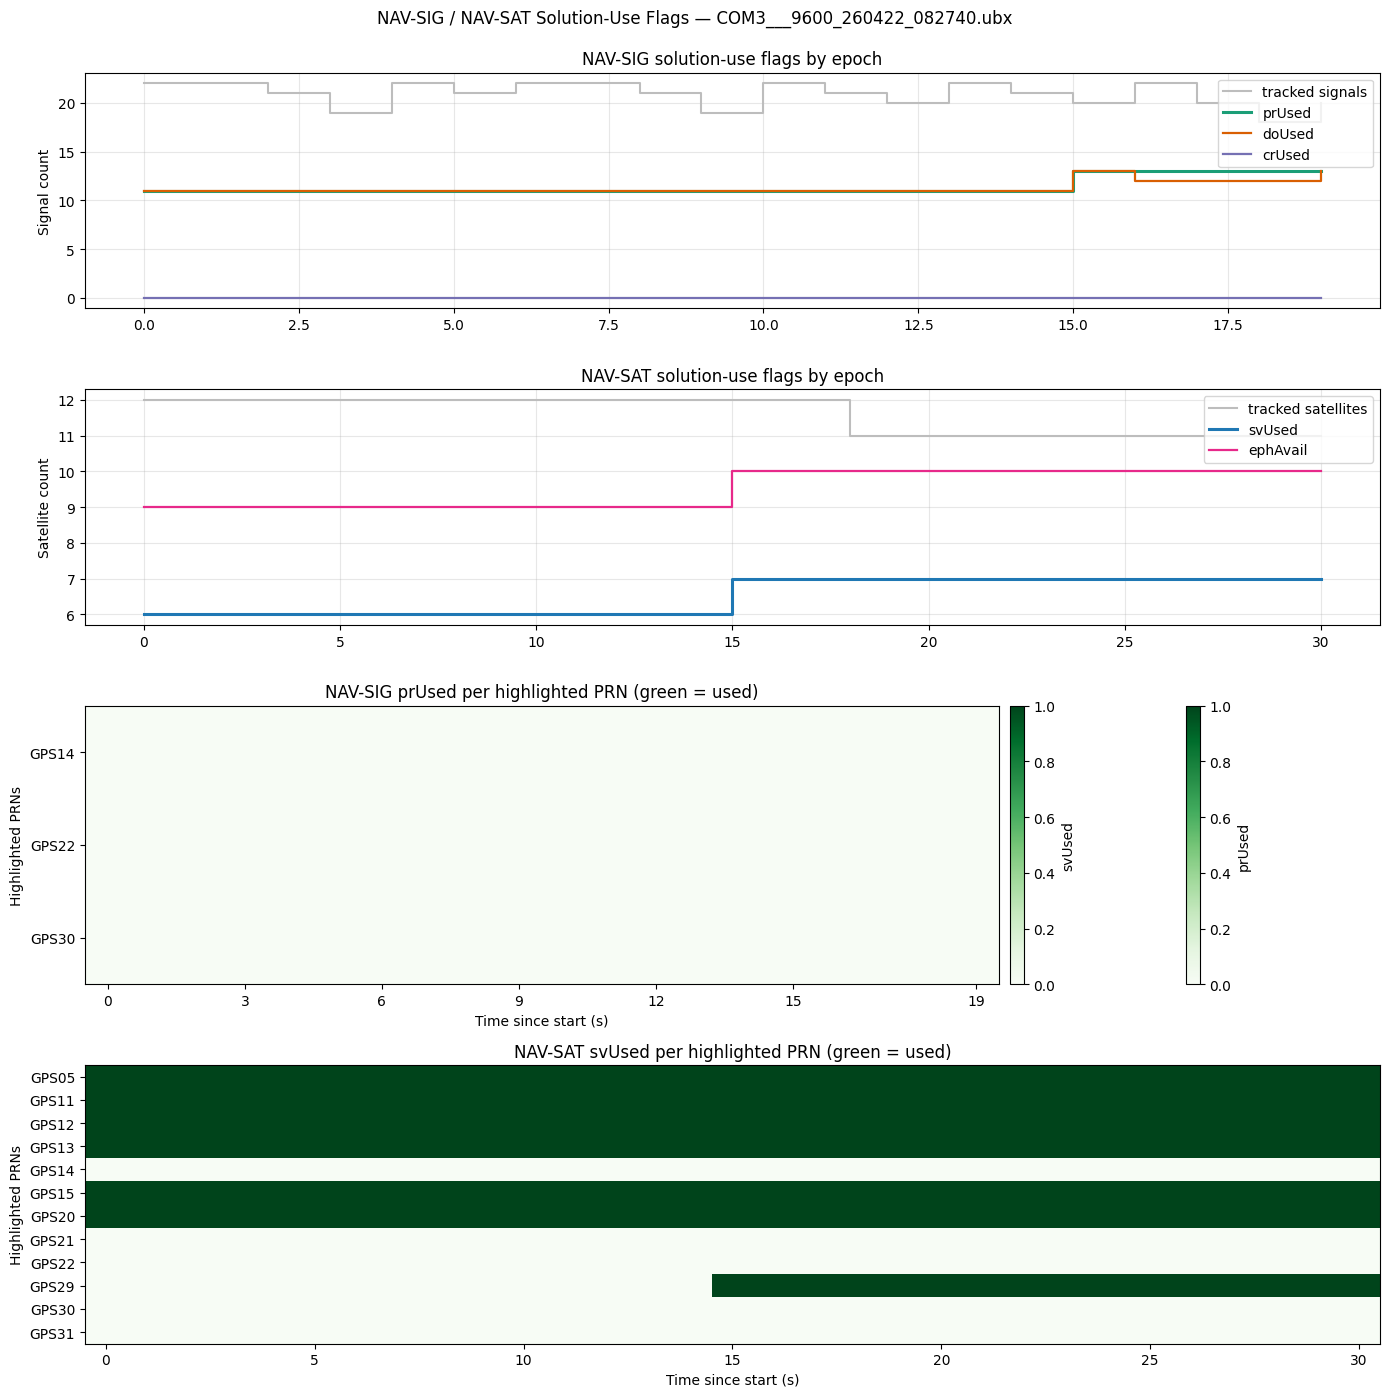

Top NAV-SIG satellites by prUsed epochs
       epochs  mean_cno  pr_used_epochs  do_used_epochs  pr_used_rate
sat                                                                  
GPS12      20    36.300              40              40           2.0
GPS15      20    35.750              40              40           2.0
GPS05      20    33.200              40              40           2.0
GPS20      20    33.175              40              40           2.0
GPS11      20    28.525              40              40           2.0
GPS13      20    21.735              20              20           1.0
GPS29      20    19.400              10               7           0.5
GPS21      20    25.450               0               0           0.0
GPS22      19    21.353               0               0           0.0
GPS30      20    21.162               0               0           0.0

Top NAV-SAT satellites by svUsed epochs
       epochs  mean_cno  sv_used_epochs  eph_available_epochs  sv_used_rate
sat

In [21]:
if nav_sig_df.empty or nav_sat_df.empty:
    print("NAV-SIG or NAV-SAT has no valid records for plotting.")
else:
    nav_sig_epoch = (
        nav_sig_df.groupby("t_sec")
        .agg(
            tracked_signals=("sat_sig", "count"),
            pr_used=("prUsed", "sum"),
            do_used=("doUsed", "sum"),
            cr_used=("crUsed", "sum"),
            mean_cno=("cno", "mean"),
        )
        .reset_index()
    )

    nav_sat_epoch = (
        nav_sat_df.groupby("t_sec")
        .agg(
            tracked_sats=("sat", "nunique"),
            sv_used=("svUsed", "sum"),
            eph_available=("ephAvail", "sum"),
            mean_cno=("cno", "mean"),
        )
        .reset_index()
    )

    highlight_tokens = {str(prn).strip().upper() for prn in HIGHLIGHT_PRNS}
    highlight_sv_ids = {int(token) for token in highlight_tokens if token.isdigit()}

    if highlight_sv_ids:
        nav_sig_heatmap = (
            nav_sig_df[nav_sig_df["svId"].isin(highlight_sv_ids)]
            .groupby(["sat", "t_sec"])["prUsed"]
            .max()
            .unstack(fill_value=0)
            .sort_index()
        )
    else:
        top_sats = (
            nav_sig_df.groupby("sat")["prUsed"]
            .sum()
            .sort_values(ascending=False)
            .head(16)
            .index
        )
        nav_sig_heatmap = (
            nav_sig_df[nav_sig_df["sat"].isin(top_sats)]
            .groupby(["sat", "t_sec"])["prUsed"]
            .max()
            .unstack(fill_value=0)
            .sort_index()
        )

    nav_sig_sat_summary = (
        nav_sig_df.groupby("sat")
        .agg(
            epochs=("iTOW_ms", "nunique"),
            mean_cno=("cno", "mean"),
            pr_used_epochs=("prUsed", "sum"),
            do_used_epochs=("doUsed", "sum"),
        )
        .assign(pr_used_rate=lambda d: d["pr_used_epochs"] / d["epochs"])
        .round(3)
        .sort_values(["pr_used_epochs", "mean_cno"], ascending=[False, False])
    )
    
    top_nav_sats = (
            nav_sat_df.groupby("sat")["svUsed"]
            .sum()
            .sort_values(ascending=False)
            .head(16)
            .index
        )
    nav_sat_heatmap = (
            nav_sat_df[nav_sat_df["sat"].isin(top_nav_sats)]
            .groupby(["sat", "t_sec"])["svUsed"]
            .max()
            .unstack(fill_value=0)
            .sort_index()
        )

    nav_sat_summary = (
        nav_sat_df.groupby("sat")
        .agg(
            epochs=("iTOW_ms", "nunique"),
            mean_cno=("cno", "mean"),
            sv_used_epochs=("svUsed", "sum"),
            eph_available_epochs=("ephAvail", "sum"),
        )
        .assign(sv_used_rate=lambda d: d["sv_used_epochs"] / d["epochs"])
        .round(3)
        .sort_values(["sv_used_epochs", "mean_cno"], ascending=[False, False])
    )

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), gridspec_kw={"height_ratios": [1.1, 1.1, 1.3, 1.3]})

    axes[0].step(nav_sig_epoch["t_sec"], nav_sig_epoch["tracked_signals"], where="post", label="tracked signals", linewidth=1.5, color="#bdbdbd")
    axes[0].step(nav_sig_epoch["t_sec"], nav_sig_epoch["pr_used"], where="post", label="prUsed", linewidth=2.2, color="#1b9e77")
    axes[0].step(nav_sig_epoch["t_sec"], nav_sig_epoch["do_used"], where="post", label="doUsed", linewidth=1.6, color="#d95f02")
    axes[0].step(nav_sig_epoch["t_sec"], nav_sig_epoch["cr_used"], where="post", label="crUsed", linewidth=1.6, color="#7570b3")
    axes[0].set_ylabel("Signal count")
    axes[0].set_title("NAV-SIG solution-use flags by epoch")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="upper right")

    axes[1].step(nav_sat_epoch["t_sec"], nav_sat_epoch["tracked_sats"], where="post", label="tracked satellites", linewidth=1.5, color="#bdbdbd")
    axes[1].step(nav_sat_epoch["t_sec"], nav_sat_epoch["sv_used"], where="post", label="svUsed", linewidth=2.2, color="#1f78b4")
    axes[1].step(nav_sat_epoch["t_sec"], nav_sat_epoch["eph_available"], where="post", label="ephAvail", linewidth=1.6, color="#e7298a")
    axes[1].set_ylabel("Satellite count")
    axes[1].set_title("NAV-SAT solution-use flags by epoch")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="upper right")

    if nav_sig_heatmap.empty:
        axes[2].text(0.5, 0.5, "No highlighted PRNs found in NAV-SIG", transform=axes[2].transAxes, ha="center", va="center")
        axes[2].set_axis_off()
    else:
        im = axes[2].imshow(nav_sig_heatmap.values, aspect="auto", interpolation="nearest", cmap="Greens", vmin=0, vmax=1)
        axes[2].set_yticks(range(len(nav_sig_heatmap.index)))
        axes[2].set_yticklabels(nav_sig_heatmap.index)
        axes[2].set_ylabel("Highlighted PRNs")
        axes[2].set_title("NAV-SIG prUsed per highlighted PRN (green = used)")

        num_cols = nav_sig_heatmap.shape[1]
        last_idx = num_cols - 1
        tick_idx = []
        for i in range(7):
            idx = last_idx * i // 6
            if idx not in tick_idx:
                tick_idx.append(idx)
        if last_idx not in tick_idx:
            tick_idx.append(last_idx)
        tick_idx = sorted(tick_idx)

        axes[2].set_xticks(tick_idx)
        axes[2].set_xticklabels([f"{nav_sig_heatmap.columns[i]:.0f}" for i in tick_idx])
        axes[2].set_xlabel("Time since start (s)")
        cbar = fig.colorbar(im, ax=axes[2], pad=0.01)
        cbar.set_label("prUsed")
        
    if nav_sat_heatmap.empty:
        axes[3].text(0.5, 0.5, "No highlighted PRNs found in NAV-SAT", transform=axes[3].transAxes, ha="center", va="center")
        axes[3].set_axis_off()
    else:
        im = axes[3].imshow(nav_sat_heatmap.values, aspect="auto", interpolation="nearest", cmap="Greens", vmin=0, vmax=1)
        axes[3].set_yticks(range(len(nav_sat_heatmap.index)))
        axes[3].set_yticklabels(nav_sat_heatmap.index)
        axes[3].set_ylabel("Highlighted PRNs")
        axes[3].set_title("NAV-SAT svUsed per highlighted PRN (green = used)")

        num_cols = nav_sat_heatmap.shape[1]
        last_idx = num_cols - 1
        tick_idx = []
        for i in range(7):
            idx = last_idx * i // 6
            if idx not in tick_idx:
                tick_idx.append(idx)
        if last_idx not in tick_idx:
            tick_idx.append(last_idx)
        tick_idx = sorted(tick_idx)

        axes[3].set_xticks(tick_idx)
        axes[3].set_xticklabels([f"{nav_sat_heatmap.columns[i]:.0f}" for i in tick_idx])
        axes[3].set_xlabel("Time since start (s)")
        cbar = fig.colorbar(im, ax=axes[2], pad=0.01)
        cbar.set_label("svUsed")

    fig.suptitle(f"NAV-SIG / NAV-SAT Solution-Use Flags — {UBX_FILE.name}", y=0.995)
    fig.tight_layout()
    plt.show()

    print("Top NAV-SIG satellites by prUsed epochs")
    print(nav_sig_sat_summary.head(10).to_string())
    print()
    print("Top NAV-SAT satellites by svUsed epochs")
    print(nav_sat_summary.head(10).to_string())


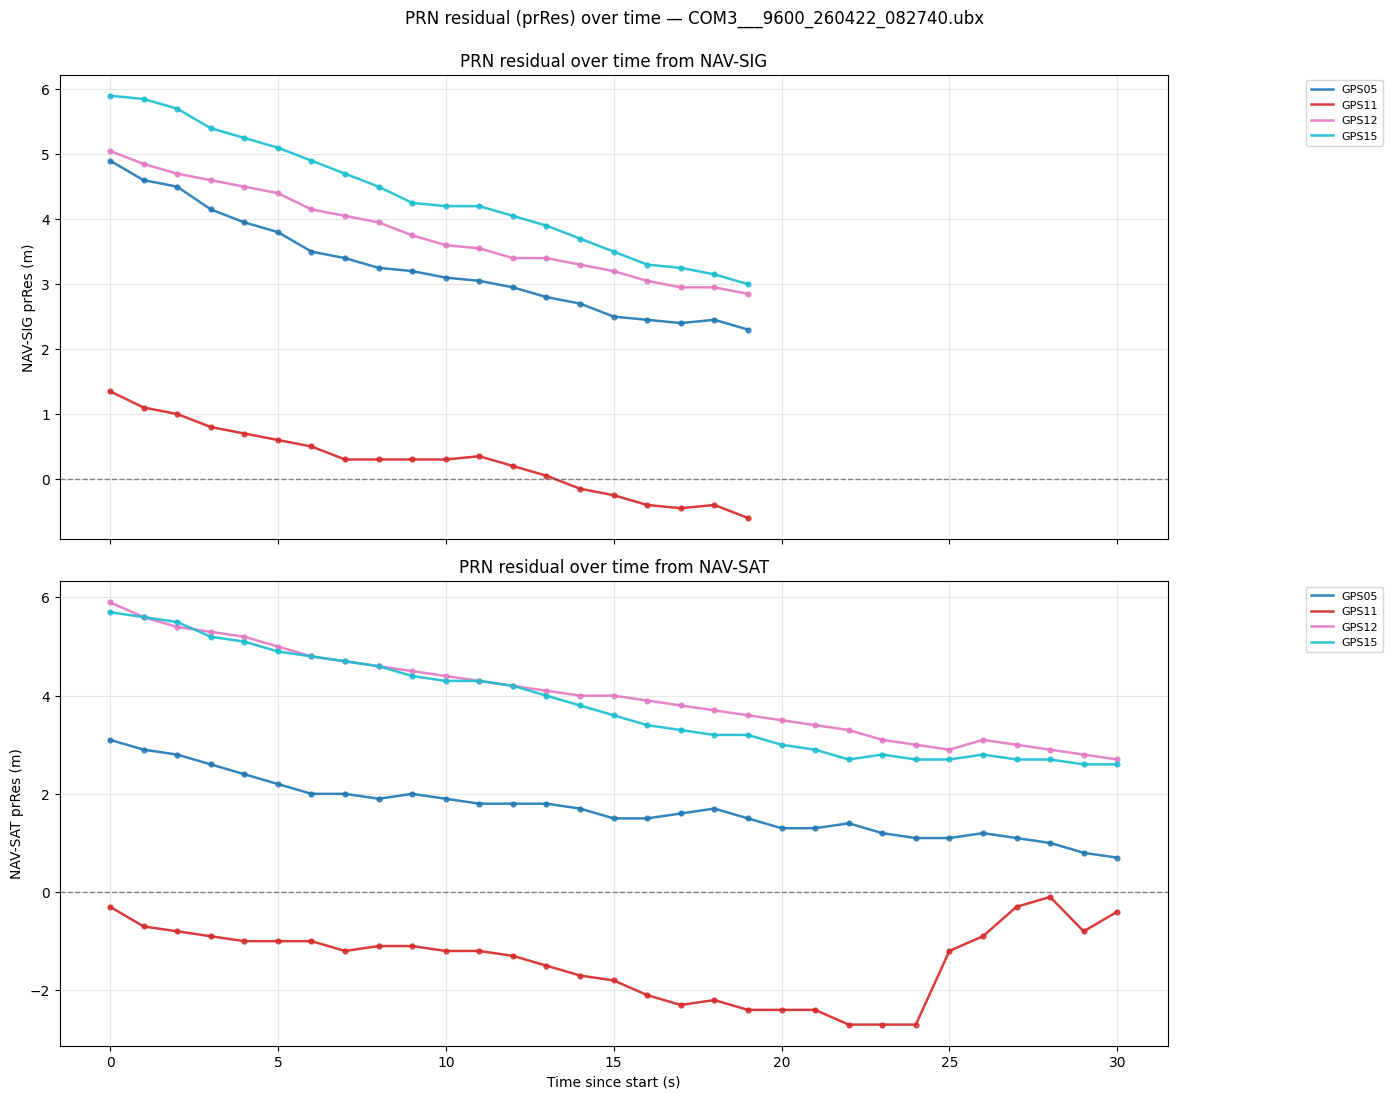

NAV-SIG PRN residual summary
       epochs  mean_prRes  mean_abs_prRes  max_abs_prRes  pr_used_epochs
sat                                                                     
GPS15      20       4.390           4.390           5.90              20
GPS12      20       3.812           3.812           5.05              20
GPS05      20       3.298           3.298           4.90              20
GPS11      20       0.280           0.505           1.35              20

NAV-SAT PRN residual summary
       epochs  mean_prRes  mean_abs_prRes  max_abs_prRes  sv_used_epochs
sat                                                                     
GPS12      31       4.023           4.023            5.9              31
GPS15      31       3.806           3.806            5.7              31
GPS05      31       1.706           1.706            3.1              31
GPS11      31      -1.400           1.400            2.7              31


In [22]:
# 10. PRN residual (prRes) over time from NAV-SIG and NAV-SAT

HIGHLIGHT_PRNS = [4, 5, 10 ,11, 12, 15, 16]
 
def _select_prn_subset(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    if df.empty:
        return df

    df = df[df[value_col].notna()].copy()
    if df.empty:
        return df

    highlight_tokens = {str(prn).strip().upper() for prn in HIGHLIGHT_PRNS}
    highlight_sv_ids = {int(token) for token in highlight_tokens if token.isdigit()}
    highlight_sat_ids = {token for token in highlight_tokens if not token.isdigit()}

    if highlight_sv_ids or highlight_sat_ids:
        mask = df["sat"].str.upper().isin(highlight_sat_ids)
        if highlight_sv_ids:
            mask = mask | df["svId"].isin(highlight_sv_ids)
        filtered = df[mask].copy()
        if not filtered.empty:
            return filtered

    top_sats = (
        df.groupby("sat")[value_col]
        .count()
        .sort_values(ascending=False)
        .head(8)
        .index
    )
    return df[df["sat"].isin(top_sats)].copy()


nav_sig_prres = _select_prn_subset(nav_sig_df, "prRes")
nav_sat_prres = _select_prn_subset(nav_sat_df, "prRes")

if nav_sig_prres.empty and nav_sat_prres.empty:
    print("No NAV-SIG or NAV-SAT prRes values available for plotting.")
else:
    all_sats = sorted(set(nav_sig_prres.get("sat", pd.Series(dtype=str))) | set(nav_sat_prres.get("sat", pd.Series(dtype=str))))
    cmap = plt.get_cmap("tab10", max(len(all_sats), 1))
    colors = {sat: cmap(i) for i, sat in enumerate(all_sats)}

    fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

    if nav_sig_prres.empty:
        axes[0].text(0.5, 0.5, "No NAV-SIG prRes values", transform=axes[0].transAxes, ha="center", va="center")
        axes[0].set_axis_off()
    else:
        # NAV-SIG can have multiple signals per PRN. Aggregate to one PRN residual per epoch.
        nav_sig_prn = (
            nav_sig_prres.groupby(["sat", "t_sec"])
            .agg(prRes=("prRes", "mean"), prUsed=("prUsed", "max"), mean_cno=("cno", "mean"))
            .reset_index()
        )

        for sat in sorted(nav_sig_prn["sat"].unique()):
            grp = nav_sig_prn[nav_sig_prn["sat"] == sat].sort_values("t_sec")
            axes[0].plot(grp["t_sec"], grp["prRes"], label=sat, color=colors[sat], linewidth=1.8, alpha=0.9)
            used = grp[grp["prUsed"] > 0]
            if not used.empty:
                axes[0].scatter(used["t_sec"], used["prRes"], color=colors[sat], s=12, alpha=0.8)

        axes[0].axhline(0, color="#555555", linewidth=1.0, linestyle="--", alpha=0.7)
        axes[0].set_ylabel("NAV-SIG prRes (m)")
        axes[0].set_title("PRN residual over time from NAV-SIG")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=8)

        nav_sig_prn_summary = (
            nav_sig_prn.groupby("sat")
            .agg(
                epochs=("t_sec", "count"),
                mean_prRes=("prRes", "mean"),
                mean_abs_prRes=("prRes", lambda s: s.abs().mean()),
                max_abs_prRes=("prRes", lambda s: s.abs().max()),
                pr_used_epochs=("prUsed", "sum"),
            )
            .round(3)
            .sort_values(["mean_abs_prRes", "epochs"], ascending=[False, False])
        )

    if nav_sat_prres.empty:
        axes[1].text(0.5, 0.5, "No NAV-SAT prRes values", transform=axes[1].transAxes, ha="center", va="center")
        axes[1].set_axis_off()
    else:
        for sat in sorted(nav_sat_prres["sat"].unique()):
            grp = nav_sat_prres[nav_sat_prres["sat"] == sat].sort_values("t_sec")
            axes[1].plot(grp["t_sec"], grp["prRes"], label=sat, color=colors[sat], linewidth=1.8, alpha=0.9)
            used = grp[grp["svUsed"] > 0]
            if not used.empty:
                axes[1].scatter(used["t_sec"], used["prRes"], color=colors[sat], s=12, alpha=0.8)

        axes[1].axhline(0, color="#555555", linewidth=1.0, linestyle="--", alpha=0.7)
        axes[1].set_xlabel("Time since start (s)")
        axes[1].set_ylabel("NAV-SAT prRes (m)")
        axes[1].set_title("PRN residual over time from NAV-SAT")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(bbox_to_anchor=(1.12, 1), loc="upper left", fontsize=8)

        nav_sat_prn_summary = (
            nav_sat_prres.groupby("sat")
            .agg(
                epochs=("t_sec", "count"),
                mean_prRes=("prRes", "mean"),
                mean_abs_prRes=("prRes", lambda s: s.abs().mean()),
                max_abs_prRes=("prRes", lambda s: s.abs().max()),
                sv_used_epochs=("svUsed", "sum"),
            )
            .round(3)
            .sort_values(["mean_abs_prRes", "epochs"], ascending=[False, False])
        )

    fig.suptitle(f"PRN residual (prRes) over time — {UBX_FILE.name}", y=0.995)
    fig.tight_layout()
    plt.show()

    if not nav_sig_prres.empty:
        print("NAV-SIG PRN residual summary")
        print(nav_sig_prn_summary.to_string())
        print()

    if not nav_sat_prres.empty:
        print("NAV-SAT PRN residual summary")
        print(nav_sat_prn_summary.to_string())


## 10. UBX-SEC-SIG Jamming and Spoofing Scan

`SEC-SIG` reports receiver signal-security state. This scan keeps one row per `SEC-SIG` epoch, extracts `jammingState`, `spoofingState`, the detector enable bits, and v2 per-center-frequency `jammed_*` flags. `SEC-SIG` does not include its own `iTOW`, so the parser also records a sequential `sec_epoch` and attaches the latest preceding UBX time source when available.

Read 12442 UBX messages, saw 255 SEC-SIG packets, skipped 0, and kept 255 SEC-SIG epochs over 254.0 s.
Jamming indicated in 0/255 SEC-SIG epochs; spoofing indicated in 0/255 SEC-SIG epochs.

SEC-SIG state counts
 jammingState jamming_label  jamming_indicated  spoofingState spoofing_label  spoofing_indicated  epochs  first_t_sec  last_t_sec
            1 not_indicated              False              1  not_indicated               False     255          0.0       254.0

SEC-SIG contiguous state intervals
 start_epoch  end_epoch  start_t_sec  end_t_sec  epochs  jammingState jamming_label  jamming_indicated  spoofingState spoofing_label  spoofing_indicated jammed_freqs
           0        254          0.0      254.0     255             1 not_indicated              False              1  not_indicated               False             

SEC-SIG per-frequency jamming summary
        freq_label  cent_freq  epochs  jammed_epochs  first_t_sec  last_t_sec  jammed_rate
L1/E1 1575.420 MHz    1575420 

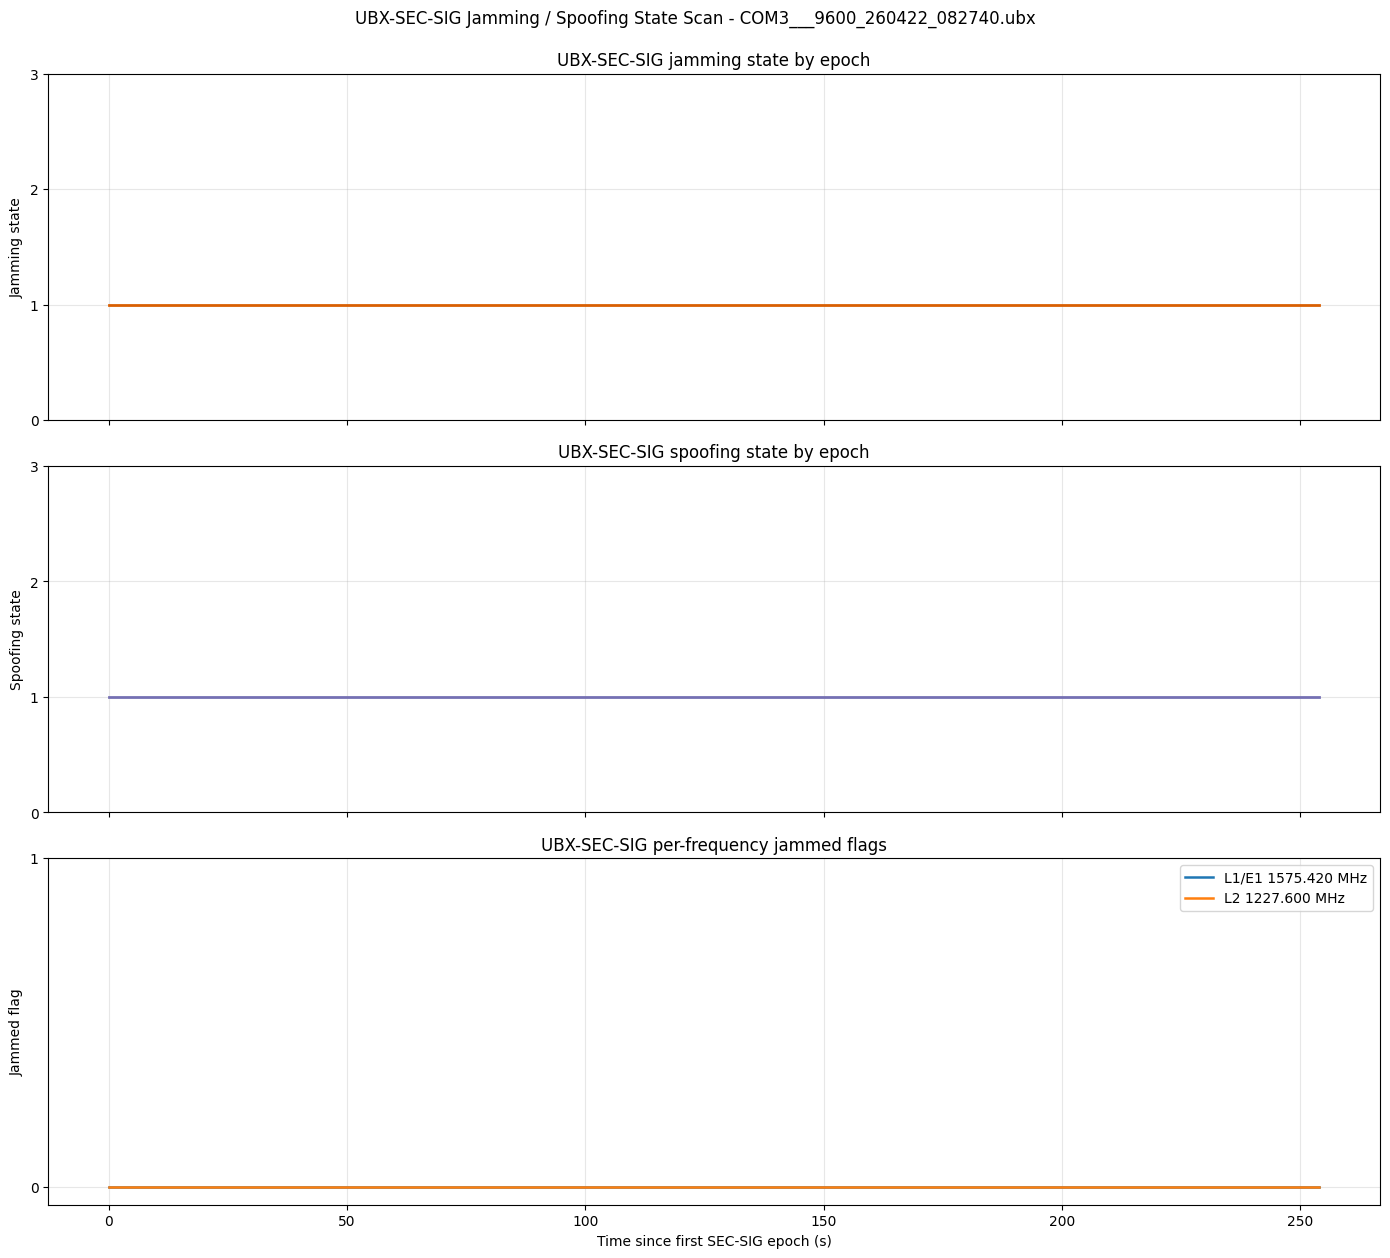

In [23]:
SEC_JAMMING_STATE_LABELS = {
    0: "disabled_or_unknown",
    1: "not_indicated",
    2: "indicated",
    3: "critical_indication",
}
SEC_SPOOFING_STATE_LABELS = {
    0: "disabled_or_unknown",
    1: "not_indicated",
    2: "indicated",
    3: "multiple_indications",
}
SEC_FREQ_LABELS = {
    1176450: "L5/E5a 1176.450 MHz",
    1207140: "E5b 1207.140 MHz",
    1227600: "L2 1227.600 MHz",
    1575420: "L1/E1 1575.420 MHz",
}


def _sec_msg_attr(msg: dict, parsed, name: str):
    if name in msg:
        return msg[name]
    return getattr(parsed, name, None)


def _sec_time_ms_from_message(msg: dict, parsed):
    i_tow_ms = _sec_msg_attr(msg, parsed, "iTOW")
    if i_tow_ms is not None:
        return int(round(i_tow_ms)), "iTOW"

    rcv_tow = _sec_msg_attr(msg, parsed, "rcvTow")
    if rcv_tow is not None:
        return int(round(float(rcv_tow) * 1000)), "rcvTow"

    return None, None


def _sec_state_label(labels: dict[int, str], state) -> str:
    if state is None or pd.isna(state):
        return "missing"
    return labels.get(int(state), f"state_{int(state)}")


def _sec_freq_label(cent_freq) -> str:
    if cent_freq is None or pd.isna(cent_freq):
        return "unknown"
    cent_freq = int(cent_freq)
    return SEC_FREQ_LABELS.get(cent_freq, f"{cent_freq / 1000:.3f} MHz")


def parse_sec_sig(filepath: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Parse every UBX-SEC-SIG epoch and return state rows plus per-frequency rows."""
    records = []
    freq_records = []
    total_messages = 0
    sec_sig_messages = 0
    skipped_sec_sig = 0
    latest_time_ms = None
    latest_time_source = None

    with open(filepath, "rb") as f:
        reader = UBXReader(f, protfilter=2)
        for raw, parsed in reader:
            if parsed is None:
                continue

            total_messages += 1
            msg = parsed.__dict__ if not hasattr(parsed, "val") else parsed.val

            if parsed.identity == "SEC-SIG":
                sec_sig_messages += 1
                version = _sec_msg_attr(msg, parsed, "version")
                jam_det_enabled = _sec_msg_attr(msg, parsed, "jamDetEnabled")
                jamming_state = _sec_msg_attr(msg, parsed, "jammingState")
                spoof_det_enabled = _sec_msg_attr(msg, parsed, "spfDetEnabled")
                spoofing_state = _sec_msg_attr(msg, parsed, "spoofingState")

                if version is None or jamming_state is None or spoofing_state is None:
                    skipped_sec_sig += 1
                    continue

                sec_epoch = len(records)
                jam_num_cent_freqs = _sec_msg_attr(msg, parsed, "jamNumCentFreqs") or 0
                jammed_freq_labels = []

                for i in range(1, int(jam_num_cent_freqs) + 1):
                    suffix = f"_{i:02d}"
                    cent_freq = _sec_msg_attr(msg, parsed, f"centFreq{suffix}")
                    jammed = _sec_msg_attr(msg, parsed, f"jammed{suffix}")
                    if cent_freq is None:
                        continue

                    freq_label = _sec_freq_label(cent_freq)
                    jammed = int(jammed or 0)
                    if jammed:
                        jammed_freq_labels.append(freq_label)

                    freq_records.append(
                        {
                            "sec_epoch": sec_epoch,
                            "message_index": total_messages,
                            "time_ms": latest_time_ms,
                            "time_source": latest_time_source,
                            "cent_freq": int(cent_freq),
                            "freq_label": freq_label,
                            "jammed": jammed,
                        }
                    )

                jamming_state = int(jamming_state)
                spoofing_state = int(spoofing_state)
                records.append(
                    {
                        "sec_epoch": sec_epoch,
                        "message_index": total_messages,
                        "time_ms": latest_time_ms,
                        "time_source": latest_time_source,
                        "version": int(version),
                        "jamDetEnabled": int(jam_det_enabled or 0),
                        "jammingState": jamming_state,
                        "jamming_label": _sec_state_label(SEC_JAMMING_STATE_LABELS, jamming_state),
                        "jamming_indicated": bool(jamming_state >= 2 or jammed_freq_labels),
                        "spfDetEnabled": int(spoof_det_enabled or 0),
                        "spoofingState": spoofing_state,
                        "spoofing_label": _sec_state_label(SEC_SPOOFING_STATE_LABELS, spoofing_state),
                        "spoofing_indicated": bool(spoofing_state >= 2),
                        "jamNumCentFreqs": int(jam_num_cent_freqs),
                        "jammed_freq_count": len(jammed_freq_labels),
                        "jammed_freqs": ", ".join(jammed_freq_labels),
                    }
                )
                continue

            msg_time_ms, msg_time_source = _sec_time_ms_from_message(msg, parsed)
            if msg_time_ms is not None:
                latest_time_ms = msg_time_ms
                latest_time_source = f"{parsed.identity}.{msg_time_source}"

    sec_sig_df = pd.DataFrame(records)
    sec_sig_freq_df = pd.DataFrame(freq_records)

    if sec_sig_df.empty:
        print(
            f"Read {total_messages} UBX messages, saw {sec_sig_messages} SEC-SIG packets, skipped {skipped_sec_sig}, and found no valid SEC-SIG states."
        )
        return sec_sig_df, sec_sig_freq_df

    if sec_sig_df["time_ms"].notna().any():
        t0_ms = sec_sig_df["time_ms"].dropna().iloc[0]
        sec_sig_df["t_sec"] = (sec_sig_df["time_ms"] - t0_ms) / 1000.0
        if not sec_sig_freq_df.empty:
            sec_sig_freq_df["t_sec"] = (sec_sig_freq_df["time_ms"] - t0_ms) / 1000.0
    else:
        sec_sig_df["t_sec"] = sec_sig_df["sec_epoch"].astype(float)
        if not sec_sig_freq_df.empty:
            sec_sig_freq_df["t_sec"] = sec_sig_freq_df["sec_epoch"].astype(float)

    span_s = sec_sig_df["t_sec"].max() - sec_sig_df["t_sec"].min()
    print(
        f"Read {total_messages} UBX messages, saw {sec_sig_messages} SEC-SIG packets, skipped {skipped_sec_sig}, and kept {len(sec_sig_df)} SEC-SIG epochs over {span_s:.1f} s."
    )
    return sec_sig_df, sec_sig_freq_df


def _sec_state_intervals(scan_df: pd.DataFrame) -> pd.DataFrame:
    if scan_df.empty:
        return pd.DataFrame()

    key_cols = ["jammingState", "spoofingState", "jammed_freqs"]
    state_key = scan_df[key_cols].astype(str).agg("|".join, axis=1)
    groups = state_key.ne(state_key.shift()).cumsum()
    return (
        scan_df.groupby(groups)
        .agg(
            start_epoch=("sec_epoch", "first"),
            end_epoch=("sec_epoch", "last"),
            start_t_sec=("t_sec", "first"),
            end_t_sec=("t_sec", "last"),
            epochs=("sec_epoch", "count"),
            jammingState=("jammingState", "first"),
            jamming_label=("jamming_label", "first"),
            jamming_indicated=("jamming_indicated", "first"),
            spoofingState=("spoofingState", "first"),
            spoofing_label=("spoofing_label", "first"),
            spoofing_indicated=("spoofing_indicated", "first"),
            jammed_freqs=("jammed_freqs", "first"),
        )
        .reset_index(drop=True)
    )


sec_sig_df, sec_sig_freq_df = parse_sec_sig(UBX_FILE)
sec_sig_epoch_scan = pd.DataFrame()
sec_sig_intervals = pd.DataFrame()
sec_sig_state_counts = pd.DataFrame()
sec_sig_freq_summary = pd.DataFrame()

if sec_sig_df.empty:
    print("No valid UBX-SEC-SIG epochs found.")
else:
    sec_sig_epoch_scan = sec_sig_df[
        [
            "sec_epoch",
            "t_sec",
            "time_source",
            "version",
            "jamDetEnabled",
            "jammingState",
            "jamming_label",
            "jamming_indicated",
            "spfDetEnabled",
            "spoofingState",
            "spoofing_label",
            "spoofing_indicated",
            "jammed_freqs",
        ]
    ].copy()
    sec_sig_intervals = _sec_state_intervals(sec_sig_epoch_scan)
    sec_sig_state_counts = (
        sec_sig_epoch_scan.groupby(
            [
                "jammingState",
                "jamming_label",
                "jamming_indicated",
                "spoofingState",
                "spoofing_label",
                "spoofing_indicated",
            ]
        )
        .agg(epochs=("sec_epoch", "count"), first_t_sec=("t_sec", "min"), last_t_sec=("t_sec", "max"))
        .reset_index()
        .sort_values(["first_t_sec", "jammingState", "spoofingState"])
    )

    print(
        f"Jamming indicated in {int(sec_sig_epoch_scan['jamming_indicated'].sum())}/{len(sec_sig_epoch_scan)} SEC-SIG epochs; "
        f"spoofing indicated in {int(sec_sig_epoch_scan['spoofing_indicated'].sum())}/{len(sec_sig_epoch_scan)} SEC-SIG epochs."
    )
    print("\nSEC-SIG state counts")
    print(sec_sig_state_counts.to_string(index=False))
    print("\nSEC-SIG contiguous state intervals")
    print(sec_sig_intervals.round(3).to_string(index=False))

    if not sec_sig_freq_df.empty:
        sec_sig_freq_summary = (
            sec_sig_freq_df.groupby(["freq_label", "cent_freq"])
            .agg(epochs=("sec_epoch", "count"), jammed_epochs=("jammed", "sum"), first_t_sec=("t_sec", "min"), last_t_sec=("t_sec", "max"))
            .assign(jammed_rate=lambda d: d["jammed_epochs"] / d["epochs"])
            .round(3)
            .reset_index()
            .sort_values(["jammed_epochs", "freq_label"], ascending=[False, True])
        )
        print("\nSEC-SIG per-frequency jamming summary")
        print(sec_sig_freq_summary.to_string(index=False))

    plot_rows = 3 if not sec_sig_freq_df.empty else 2
    fig, axes = plt.subplots(plot_rows, 1, figsize=(14, 4.2 * plot_rows), sharex=True)

    axes[0].step(sec_sig_epoch_scan["t_sec"], sec_sig_epoch_scan["jammingState"], where="post", color="#d95f02", linewidth=2.0)
    jam_indicated = sec_sig_epoch_scan[sec_sig_epoch_scan["jamming_indicated"]]
    if not jam_indicated.empty:
        axes[0].scatter(jam_indicated["t_sec"], jam_indicated["jammingState"], color="#b2182b", s=20, label="jamming indicated", zorder=3)
        axes[0].legend(loc="upper right")
    axes[0].set_ylabel("Jamming state")
    axes[0].set_yticks([0, 1, 2, 3])
    axes[0].set_title("UBX-SEC-SIG jamming state by epoch")
    axes[0].grid(True, alpha=0.3)

    axes[1].step(sec_sig_epoch_scan["t_sec"], sec_sig_epoch_scan["spoofingState"], where="post", color="#7570b3", linewidth=2.0)
    spoof_indicated = sec_sig_epoch_scan[sec_sig_epoch_scan["spoofing_indicated"]]
    if not spoof_indicated.empty:
        axes[1].scatter(spoof_indicated["t_sec"], spoof_indicated["spoofingState"], color="#542788", s=20, label="spoofing indicated", zorder=3)
        axes[1].legend(loc="upper right")
    axes[1].set_ylabel("Spoofing state")
    axes[1].set_yticks([0, 1, 2, 3])
    axes[1].set_title("UBX-SEC-SIG spoofing state by epoch")
    axes[1].grid(True, alpha=0.3)

    if not sec_sig_freq_df.empty:
        for freq_label, grp in sec_sig_freq_df.groupby("freq_label"):
            grp = grp.sort_values("t_sec")
            axes[2].step(grp["t_sec"], grp["jammed"], where="post", label=freq_label, linewidth=1.8)
        axes[2].set_ylabel("Jammed flag")
        axes[2].set_yticks([0, 1])
        axes[2].set_title("UBX-SEC-SIG per-frequency jammed flags")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend(loc="upper right")

    axes[-1].set_xlabel("Time since first SEC-SIG epoch (s)")
    fig.suptitle(f"UBX-SEC-SIG Jamming / Spoofing State Scan - {UBX_FILE.name}", y=0.995)
    fig.tight_layout()
    plt.show()
